#### Importing the required libraries

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from IPython.core.display import display, HTML
display(HTML("<style>.container {width:100% !important;}</style>"))

In [2]:
raw0 = pd.read_csv('london_merged.csv')

In [3]:
raw0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
timestamp       17414 non-null object
cnt             17414 non-null int64
t1              17414 non-null float64
t2              17414 non-null float64
hum             17414 non-null float64
wind_speed      17414 non-null float64
weather_code    17414 non-null float64
is_holiday      17414 non-null float64
is_weekend      17414 non-null float64
season          17414 non-null float64
dtypes: float64(8), int64(1), object(1)
memory usage: 1.3+ MB


In [4]:
raw0.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [6]:
type(raw0.timestamp[0])

str

In [8]:
raw0.timestamp.apply(type).value_counts()

<class 'str'>    17414
Name: timestamp, dtype: int64

#### Convert timestamp to a datetime value

In [9]:
bike1 = raw0.copy()

In [12]:
bike1.timestamp = pd.to_datetime(bike1.timestamp)

In [13]:
bike1.timestamp.apply(type).value_counts()

<class 'pandas._libs.tslibs.timestamps.Timestamp'>    17414
Name: timestamp, dtype: int64

In [14]:
bike1.timestamp.describe()

count                   17414
unique                  17414
top       2015-09-21 23:00:00
freq                        1
first     2015-01-04 00:00:00
last      2017-01-03 23:00:00
Name: timestamp, dtype: object

#### Extract dates from the timestamps

In [15]:
bike1['date'] = bike1.timestamp.dt.date

In [16]:
bike1.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season,date
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0,2015-01-04
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0,2015-01-04
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0,2015-01-04
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0,2015-01-04
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0,2015-01-04


In [17]:
bike1.tail()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season,date
17409,2017-01-03 19:00:00,1042,5.0,1.0,81.0,19.0,3.0,0.0,0.0,3.0,2017-01-03
17410,2017-01-03 20:00:00,541,5.0,1.0,81.0,21.0,4.0,0.0,0.0,3.0,2017-01-03
17411,2017-01-03 21:00:00,337,5.5,1.5,78.5,24.0,4.0,0.0,0.0,3.0,2017-01-03
17412,2017-01-03 22:00:00,224,5.5,1.5,76.0,23.0,4.0,0.0,0.0,3.0,2017-01-03
17413,2017-01-03 23:00:00,139,5.0,1.0,76.0,22.0,2.0,0.0,0.0,3.0,2017-01-03


#### Daily trend of rides

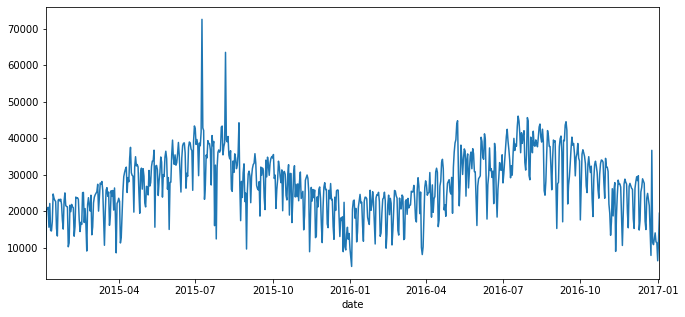

In [18]:
bike1.groupby('date')['cnt'].sum().plot(figsize=[11,5])
plt.show()

#### Create a month column

In [19]:
bike1['monthnum'] = bike1.timestamp.dt.month

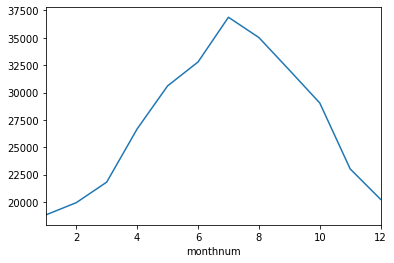

In [21]:
bike1.groupby(['monthnum','date'])['cnt'].sum().groupby(['monthnum']).mean().plot()
plt.show()

In [23]:
bike1.season.value_counts()

0.0    4394
1.0    4387
3.0    4330
2.0    4303
Name: season, dtype: int64

In [24]:
bike1.groupby(['season','monthnum']).size()

season  monthnum
0.0     3           1468
        4           1438
        5           1488
1.0     6           1422
        7           1481
        8           1484
2.0     9           1394
        10          1479
        11          1430
3.0     1           1487
        2           1359
        12          1484
dtype: int64

0: Spring  
1: Summer  
2: Fall  
3: Winter

#### Assessing the patterns in the week

In [25]:
?bike1.timestamp.dt.dayofweek

In [26]:
bike1['dayinweek'] = bike1.timestamp.dt.dayofweek

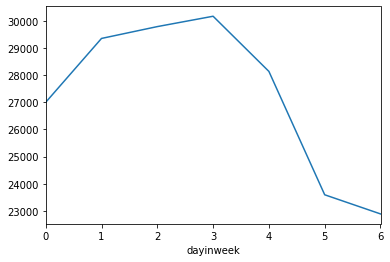

In [27]:
bike1.groupby(['dayinweek','date'])['cnt'].sum().groupby(['dayinweek']).mean().plot()
plt.show()

In [28]:
bike1['flag_weekend'] = np.where(bike1.dayinweek.isin([5,6]),1,0)

In [29]:
bike1.groupby(['is_weekend', 'flag_weekend']).size()

is_weekend  flag_weekend
0.0         0               12444
1.0         1                4970
dtype: int64

#### Analyze rides by hour of the day

In [30]:
bike1['hourinday'] = bike1.timestamp.dt.hour

In [31]:
bike1.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season,date,monthnum,dayinweek,flag_weekend,hourinday
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0,2015-01-04,1,6,1,0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0,2015-01-04,1,6,1,1
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0,2015-01-04,1,6,1,2
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0,2015-01-04,1,6,1,3
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0,2015-01-04,1,6,1,4


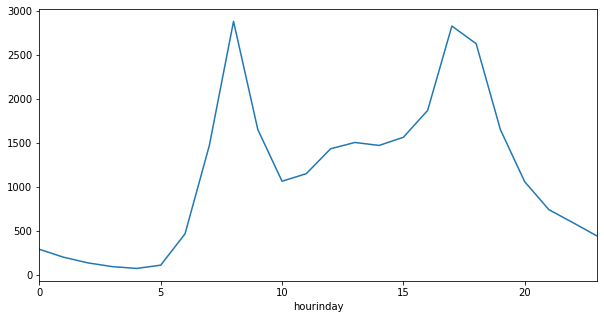

In [33]:
bike1.groupby('hourinday')['cnt'].mean().plot(figsize=[10,5])
plt.show()

In [34]:
peak_hours = [7,8,9,16,17,18]

In [35]:
bike1['flag_peakhr'] = np.where(bike1.hourinday.isin(peak_hours), 1, 0)

#### Holidays vs. other days

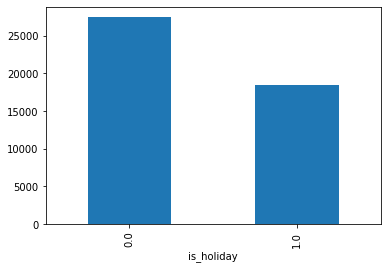

In [37]:
bike1.groupby(['is_holiday','date'])['cnt'].sum().groupby(['is_holiday']).mean().plot.bar()
plt.show()